# 02 · Grid Isochrones — Four Travel Modes
**15-Minute Shanghai | Track B — Entertainment & Nightlife**

This notebook computes 15-minute reachability polygons (isochrones) for every grid centroid across four travel modes. It picks up directly from `grid_master.geojson` produced in `01_data_collection.ipynb`.

| Mode | Speed | 15-min reach | Feeds baseline score? |
|---|---|---|---|
| A — Walk | 5 km/h | 1,250 m network | ✅ Yes |
| B — Cycling / e-bike | 12 km/h | 3,000 m network | ✅ Yes |
| C — Transit (metro + walk) | GTFS-based | station graph | ✅ Yes |
| D — Drive | 30 km/h avg | 7,500 m network | ❌ Comparison only |

> **Cache discipline:** every result is written to `.parquet` immediately. If the kernel dies, re-running skips already-computed centroids. Never recompute what you already have.

**Method:** `osmnx` pedestrian/bike/drive network + `networkx` ego-graph Dijkstra — mirrors teacher's `graph_tool` + `policosm` approach but runs on Kaggle without private dependencies.

**Backup strategies (auto-activated if slow):**
- Transit GTFS too complex → Euclidean proxy: stations within 1,500 m
- Full city too slow → pilot on 8 central districts, scale after validation

## Local Shanghai Road Network

The original implementation downloaded the Shanghai road network directly from OpenStreetMap using OSMnx. However, downloading large OSM networks inside Kaggle is slow and unstable because it depends on external Overpass API requests.

To improve reproducibility and runtime efficiency, this notebook uses a teacher-provided preprocessed Shanghai road network file: `shanghai-roads-simplified.parquet`. The road network was originally extracted from OpenStreetMap using `policosm`, projected to EPSG:4576, simplified, and exported as a local parquet file.

In this notebook, I do not rerun `policosm` or download OSM data again. Instead, I load the preprocessed road network directly, compute travel-time weights for walking, cycling, and driving, and build NetworkX graphs for isochrone analysis.

---
## 0 · Setup

In [36]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "osmnx", "networkx", "shapely", "geopandas",
                "pyproj", "pandas", "numpy", "tqdm", "folium"])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'osmnx', 'networkx', 'shapely', 'geopandas', 'pyproj', 'pandas', 'numpy', 'tqdm', 'folium'], returncode=0)

In [37]:
import os, time, warnings, zipfile, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import folium
import matplotlib.pyplot as plt

from shapely.geometry import Point, MultiPoint, Polygon, mapping
from shapely.ops import unary_union
from pyproj import Transformer
from tqdm.auto import tqdm

ox.settings.log_console = False
ox.settings.use_cache   = True          # osmnx built-in tile cache

WGS84  = "EPSG:4326"
UTM51N = "EPSG:32651"

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE       = "/kaggle/input/datasets/minghaomei/availabledata/"
DATA       = os.path.join(BASE, "data")
GRID_PATH  = "/kaggle/working/grid_master.geojson"   # from notebook 01
OUT_DIR    = "/kaggle/working/iso/"
os.makedirs(OUT_DIR, exist_ok=True)

WALK_OUT    = os.path.join(OUT_DIR, "iso_walk.parquet")
BIKE_OUT    = os.path.join(OUT_DIR, "iso_bike.parquet")
TRANSIT_OUT = os.path.join(OUT_DIR, "iso_transit.parquet")
DRIVE_OUT   = os.path.join(OUT_DIR, "iso_drive.parquet")

# ── 15-min travel distances (metres) ─────────────────────────────────────────
WALK_DIST    = 1_250   # 5 km/h × 15 min
BIKE_DIST    = 3_000   # 12 km/h × 15 min
DRIVE_DIST   = 7_500   # 30 km/h × 15 min
TRANSIT_WALK =   500   # max walk to station
TRANSIT_RIDE = 5_250   # 9 min remaining × 35 km/h

print("Setup complete.")
print(f"Walk reach  : {WALK_DIST:,} m")
print(f"Bike reach  : {BIKE_DIST:,} m")
print(f"Drive reach : {DRIVE_DIST:,} m")
print(f"Transit     : walk ≤{TRANSIT_WALK} m + ride ≤{TRANSIT_RIDE:,} m")

Setup complete.
Walk reach  : 1,250 m
Bike reach  : 3,000 m
Drive reach : 7,500 m
Transit     : walk ≤500 m + ride ≤5,250 m


---
## 1 · Load grid_master

In [38]:
grid = gpd.read_file(GRID_PATH)
print(f"Grid cells loaded : {len(grid):,}")
print(f"Columns           : {grid.columns.tolist()}")
grid.head(3)

Grid cells loaded : 31,374
Columns           : ['cell_id', 'lon', 'lat', 'h3_index', 'district', 'subdistrict', 'ring_zone', 'geometry']


,cell_id,lon,lat,h3_index,district,subdistrict,ring_zone,geometry
0,SH_000000,120.8531,31.1053,88309870cbfffff,None,???,new_town,POINT (120.85313 31.10526)
1,SH_000001,120.8584,31.1053,88309870cbfffff,上海市,???,new_town,POINT (120.85837 31.10535)
2,SH_000002,120.8583,31.1099,88309870cbfffff,None,???,new_town,POINT (120.85827 31.10986)


---
## 2 · upload shanghai-roads-simplified.parquet


and I think :to avoid repeated online OSM downloads in Kaggle, I used the teacher-provided preprocessed Shanghai road network. The network was originally extracted from OSM using policosm, projected to EPSG:4576, simplified, and exported as a local parquet file. I then reused the road attributes and computed travel-time weights for walking, cycling, and driving following the teacher’s speed assumptions.

In [39]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

input/
  datasets/
    minghaomei/
      newdata/
        shanghai-roads-simplified.parquet
      availabledata/
        data/
          utseus-anjuke-real-estate.pk
          sh-villages.geojson
          sh-neighbourhoods.geojson
          shanghai-full-buildings.parquet
          sh-towns.geojson
          sh-province-district.geojson
          poi/
            -POI.shx
            -POI.dbf
            -POI.prj
            -POI.shp
            -POI.cpg


In [40]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

from shapely.geometry import Point, MultiPoint
from scipy.spatial import cKDTree

SPEED_WALK = 1.33
SPEED_BIKE = 3.05
SPEED_CAR  = 8.30

ROAD_CRS = "EPSG:4576"
WGS84 = "EPSG:4326"

ROAD_PATH = "/kaggle/input/datasets/minghaomei/newdata/shanghai-roads-simplified.parquet"

roads = gpd.read_parquet(ROAD_PATH)

if roads.crs is None:
    roads = roads.set_crs(ROAD_CRS)
else:
    roads = roads.to_crs(ROAD_CRS)

roads = roads.dropna(subset=["geometry"]).copy()
roads = roads[roads.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
roads = roads.explode(index_parts=False).reset_index(drop=True)

roads["length_m"] = roads.geometry.length

roads["foot_time"] = roads["length_m"] / SPEED_WALK
roads["bicycle_time"] = roads["length_m"] / SPEED_BIKE
roads["car_time"] = roads["length_m"] / SPEED_CAR

gdf_walk = roads[roads["foot"].fillna(0) > 0].copy()
gdf_bike = roads[roads["bicycle"].fillna(0) > 0].copy()
gdf_drive = roads[roads["level"].fillna(0) >= 3].copy()

print("All road segments:", len(roads))
print("Walk segments:", len(gdf_walk))
print("Bike segments:", len(gdf_bike))
print("Drive segments:", len(gdf_drive))

All road segments: 156432
Walk segments: 150992
Bike segments: 101470
Drive segments: 94399


In [41]:
def edge_endpoints(row):
    geom = row.geometry
    coords = list(geom.coords)

    x0, y0 = coords[0]
    x1, y1 = coords[-1]

    if "u" in row.index and "v" in row.index and pd.notna(row["u"]) and pd.notna(row["v"]):
        u = row["u"]
        v = row["v"]
    else:
        u = (round(x0, 3), round(y0, 3))
        v = (round(x1, 3), round(y1, 3))

    return u, v, x0, y0, x1, y1


def build_nx_graph(edge_gdf, time_col, mode_label):
    G = nx.Graph()

    for _, row in edge_gdf.iterrows():
        try:
            u, v, x0, y0, x1, y1 = edge_endpoints(row)

            travel_time = float(row[time_col])

            if not np.isfinite(travel_time) or travel_time <= 0:
                continue

            if u not in G:
                G.add_node(u, x=float(x0), y=float(y0))

            if v not in G:
                G.add_node(v, x=float(x1), y=float(y1))

            G.add_edge(
                u,
                v,
                travel_time=travel_time,
                length=float(row.geometry.length),
                geometry=row.geometry
            )

        except Exception:
            continue

    node_ids = list(G.nodes)
    node_xy = np.array([(G.nodes[n]["x"], G.nodes[n]["y"]) for n in node_ids])

    G.graph["node_ids"] = node_ids
    G.graph["node_xy"] = node_xy
    G.graph["kdtree"] = cKDTree(node_xy)
    G.graph["crs"] = ROAD_CRS
    G.graph["mode_label"] = mode_label

    print(
        f"{mode_label}: {G.number_of_nodes():,} nodes, "
        f"{G.number_of_edges():,} edges"
    )

    return G


G_walk = build_nx_graph(gdf_walk, "foot_time", "walk")
G_bike = build_nx_graph(gdf_bike, "bicycle_time", "bike")
G_drive = build_nx_graph(gdf_drive, "car_time", "drive")

walk: 107,736 nodes, 149,131 edges
bike: 73,362 nodes, 100,815 edges
drive: 68,010 nodes, 93,976 edges


---
## 3 · Core isochrone function

For each centroid:
1. Snap to nearest graph node (osmnx `nearest_nodes`)
2. Run Dijkstra ego-graph up to `max_dist` seconds of travel time
3. Return the **convex hull** of all reachable node coordinates as a Shapely polygon

This is the same logic as teacher's `VisitorIsochrone(gt.search.DijkstraVisitor)` in cell [26], rewritten with `networkx.ego_graph`.

In [42]:
def nearest_local_node(G, lat: float, lon: float):
    """
    Find the nearest graph node to one WGS84 origin point.

    The graph nodes are stored in projected coordinates, EPSG:4576.
    The input lat/lon is WGS84, so it is first reprojected to the graph CRS.
    """
    origin_wgs = gpd.GeoSeries([Point(lon, lat)], crs=WGS84)
    origin_proj = origin_wgs.to_crs(G.graph["crs"]).iloc[0]

    _, idx = G.graph["kdtree"].query([origin_proj.x, origin_proj.y], k=1)

    return G.graph["node_ids"][int(idx)]


def make_isochrone_polygon(G, lat: float, lon: float,
                            max_seconds: float,
                            weight: str = "travel_time") -> Polygon | None:
    """
    Compute an isochrone polygon for one origin point using the local road graph.

    Parameters
    ----------
    G           : NetworkX graph built from the teacher-provided road network
    lat, lon    : origin coordinates in WGS84
    max_seconds : travel time budget in seconds, e.g. 15*60 = 900
    weight      : edge attribute used as travel-time cost

    Returns
    -------
    Shapely Polygon or None if fewer than 3 reachable nodes.
    """
    try:
        # Snap origin to nearest local road-network node
        orig_node = nearest_local_node(G, lat, lon)

        # Dijkstra search: all nodes reachable within travel-time budget
        lengths = nx.single_source_dijkstra_path_length(
            G,
            orig_node,
            cutoff=max_seconds,
            weight=weight
        )

        if len(lengths) < 3:
            return None

        # Collect reachable node coordinates in projected CRS
        node_pts = [
            Point(G.nodes[n]["x"], G.nodes[n]["y"])
            for n in lengths.keys()
            if "x" in G.nodes[n] and "y" in G.nodes[n]
        ]

        if len(node_pts) < 3:
            return None

        # Convex hull in projected CRS, so area is in square meters
        poly_proj = MultiPoint(node_pts).convex_hull

        if poly_proj.is_empty:
            return None

        # Convert geometry back to WGS84 for saving with the rest of the project
        poly_wgs = (
            gpd.GeoSeries([poly_proj], crs=G.graph["crs"])
            .to_crs(WGS84)
            .iloc[0]
        )

        return poly_wgs

    except Exception:
        return None


def batch_isochrones(G, grid_df: gpd.GeoDataFrame,
                      max_seconds: float,
                      out_path: str,
                      mode_label: str) -> gpd.GeoDataFrame:
    """
    Compute isochrones for all centroids with resume-from-cache support.

    - Loads existing parquet if present and skips already-done cell_ids
    - Processes remaining in batches of 500
    - Saves checkpoint every batch
    - Returns complete GeoDataFrame
    """
    # ── resume from cache ────────────────────────────────────────────────────
    if os.path.exists(out_path):
        done = gpd.read_parquet(out_path)
        done_ids = set(done["cell_id"])
        remaining = grid_df[~grid_df["cell_id"].isin(done_ids)].copy()
        results = [done]

        print(
            f"[{mode_label}] Resuming: {len(done_ids):,} done, "
            f"{len(remaining):,} remaining"
        )

    else:
        remaining = grid_df.copy()
        results = []

        print(
            f"[{mode_label}] Starting from scratch: "
            f"{len(remaining):,} centroids"
        )

    if len(remaining) == 0:
        print(f"[{mode_label}] Already complete ✅")
        return gpd.read_parquet(out_path)

    # ── batch processing ─────────────────────────────────────────────────────
    BATCH = 500
    rows = []

    for i, (_, cell) in enumerate(
        tqdm(
            remaining.iterrows(),
            total=len(remaining),
            desc=mode_label
        )
    ):
        poly = make_isochrone_polygon(
            G,
            cell["lat"],
            cell["lon"],
            max_seconds
        )

        if poly is not None:
            # area should be calculated in projected CRS, not WGS84 degrees
            poly_proj = (
                gpd.GeoSeries([poly], crs=WGS84)
                .to_crs(G.graph["crs"])
                .iloc[0]
            )
            area_m2 = float(poly_proj.area)
        else:
            area_m2 = None

        rows.append({
            "cell_id"      : cell["cell_id"],
            "lon"          : cell["lon"],
            "lat"          : cell["lat"],
            "h3_index"     : cell["h3_index"],
            "district"     : cell["district"],
            "ring_zone"    : cell["ring_zone"],
            "mode"         : mode_label,
            "iso_area_m2"  : area_m2,
            "geometry"     : poly
        })

        # checkpoint every BATCH rows
        if (i + 1) % BATCH == 0:
            batch_gdf = gpd.GeoDataFrame(rows, crs=WGS84)
            results.append(batch_gdf)

            merged = gpd.GeoDataFrame(
                pd.concat(results, ignore_index=True),
                crs=WGS84
            )

            merged.to_parquet(out_path)
            rows = []

            print(f"  checkpoint saved ({len(merged):,} total)")

    # final save
    if rows:
        results.append(gpd.GeoDataFrame(rows, crs=WGS84))

    final = gpd.GeoDataFrame(
        pd.concat(results, ignore_index=True),
        crs=WGS84
    )

    final.to_parquet(out_path)

    print(f"[{mode_label}] Complete ✅  {len(final):,} rows → {out_path}")

    return final


print("Isochrone functions defined using local road-network graphs.")

Isochrone functions defined using local road-network graphs.


---
## 4 · Mode A — Walking (1,250 m / 15 min)

In [43]:
# 15 min = 900 seconds
iso_walk = batch_isochrones(
    G_walk, grid,
    max_seconds = 15 * 60,
    out_path    = WALK_OUT,
    mode_label  = 'walk'
)

print(f"\nWalk isochrones summary:")
print(f"  Total rows   : {len(iso_walk):,}")
print(f"  NaN polygons : {iso_walk.geometry.isna().sum()}")
print(f"  Mean area    : {iso_walk.iso_area_m2.mean()/1e6:.3f} km²")
print(f"  (expected ~{3.14159 * 1250**2 / 1e6:.2f} km² for circle radius 1,250 m)")

[walk] Starting from scratch: 31,374 centroids


walk:   0%|          | 0/31374 [00:00<?, ?it/s]

  checkpoint saved (500 total)
  checkpoint saved (1,000 total)
  checkpoint saved (1,500 total)
  checkpoint saved (2,000 total)
  checkpoint saved (2,500 total)
  checkpoint saved (3,000 total)
  checkpoint saved (3,500 total)
  checkpoint saved (4,000 total)
  checkpoint saved (4,500 total)
  checkpoint saved (5,000 total)
  checkpoint saved (5,500 total)
  checkpoint saved (6,000 total)
  checkpoint saved (6,500 total)
  checkpoint saved (7,000 total)
  checkpoint saved (7,500 total)
  checkpoint saved (8,000 total)
  checkpoint saved (8,500 total)
  checkpoint saved (9,000 total)
  checkpoint saved (9,500 total)
  checkpoint saved (10,000 total)
  checkpoint saved (10,500 total)
  checkpoint saved (11,000 total)
  checkpoint saved (11,500 total)
  checkpoint saved (12,000 total)
  checkpoint saved (12,500 total)
  checkpoint saved (13,000 total)
  checkpoint saved (13,500 total)
  checkpoint saved (14,000 total)
  checkpoint saved (14,500 total)
  checkpoint saved (15,000 total)
 

---
## 5 · Mode B — Cycling / e-bike (3,000 m / 15 min)

In [44]:
iso_bike = batch_isochrones(
    G_bike, grid,
    max_seconds = 15 * 60,
    out_path    = BIKE_OUT,
    mode_label  = 'bike'
)

print(f"\nBike isochrones summary:")
print(f"  Total rows   : {len(iso_bike):,}")
print(f"  NaN polygons : {iso_bike.geometry.isna().sum()}")
print(f"  Mean area    : {iso_bike.iso_area_m2.mean()/1e6:.3f} km²")
print(f"  (expected ~{3.14159 * 3000**2 / 1e6:.2f} km² for circle radius 3,000 m)")

[bike] Starting from scratch: 31,374 centroids


bike:   0%|          | 0/31374 [00:00<?, ?it/s]

  checkpoint saved (500 total)
  checkpoint saved (1,000 total)
  checkpoint saved (1,500 total)
  checkpoint saved (2,000 total)
  checkpoint saved (2,500 total)
  checkpoint saved (3,000 total)
  checkpoint saved (3,500 total)
  checkpoint saved (4,000 total)
  checkpoint saved (4,500 total)
  checkpoint saved (5,000 total)
  checkpoint saved (5,500 total)
  checkpoint saved (6,000 total)
  checkpoint saved (6,500 total)
  checkpoint saved (7,000 total)
  checkpoint saved (7,500 total)
  checkpoint saved (8,000 total)
  checkpoint saved (8,500 total)
  checkpoint saved (9,000 total)
  checkpoint saved (9,500 total)
  checkpoint saved (10,000 total)
  checkpoint saved (10,500 total)
  checkpoint saved (11,000 total)
  checkpoint saved (11,500 total)
  checkpoint saved (12,000 total)
  checkpoint saved (12,500 total)
  checkpoint saved (13,000 total)
  checkpoint saved (13,500 total)
  checkpoint saved (14,000 total)
  checkpoint saved (14,500 total)
  checkpoint saved (15,000 total)
 

---
## 6 · Mode D — Driving (7,500 m / 15 min) — comparison only ⚠️

In [45]:
# ⚠️  Car isochrones are for spatial comparison ONLY.
# They do NOT feed the baseline score or Track B score.
# Label is 'drive_COMPARISON' to make this explicit in all downstream outputs.

iso_drive = batch_isochrones(
    G_drive, grid,
    max_seconds = 15 * 60,
    out_path    = DRIVE_OUT,
    mode_label  = 'drive_COMPARISON'
)

print(f"\nDrive isochrones summary (COMPARISON ONLY):")
print(f"  Total rows   : {len(iso_drive):,}")
print(f"  NaN polygons : {iso_drive.geometry.isna().sum()}")
print(f"  Mean area    : {iso_drive.iso_area_m2.mean()/1e6:.3f} km²")

[drive_COMPARISON] Starting from scratch: 31,374 centroids


drive_COMPARISON:   0%|          | 0/31374 [00:00<?, ?it/s]

  checkpoint saved (500 total)
  checkpoint saved (1,000 total)
  checkpoint saved (1,500 total)
  checkpoint saved (2,000 total)
  checkpoint saved (2,500 total)
  checkpoint saved (3,000 total)
  checkpoint saved (3,500 total)
  checkpoint saved (4,000 total)
  checkpoint saved (4,500 total)
  checkpoint saved (5,000 total)
  checkpoint saved (5,500 total)
  checkpoint saved (6,000 total)
  checkpoint saved (6,500 total)
  checkpoint saved (7,000 total)
  checkpoint saved (7,500 total)
  checkpoint saved (8,000 total)
  checkpoint saved (8,500 total)
  checkpoint saved (9,000 total)
  checkpoint saved (9,500 total)
  checkpoint saved (10,000 total)
  checkpoint saved (10,500 total)
  checkpoint saved (11,000 total)
  checkpoint saved (11,500 total)
  checkpoint saved (12,000 total)
  checkpoint saved (12,500 total)
  checkpoint saved (13,000 total)
  checkpoint saved (13,500 total)
  checkpoint saved (14,000 total)
  checkpoint saved (14,500 total)
  checkpoint saved (15,000 total)
 

---
## 7 · Mode C — Transit (metro + walk)

**Method:** GTFS-based station graph
1. Load Shanghai Metro station locations
2. For each centroid: find stations within 500 m walk (`TRANSIT_WALK`)
3. From those stations: find all stations reachable in remaining time (900 − walk_time) via the metro graph
4. Union of reachable station catchments = transit isochrone

**Fallback (auto):** if no GTFS file found → Euclidean proxy: count of metro stations within 1,500 m. Stores `proxy=True` flag so downstream scoring can weight accordingly.

In [47]:
# ── Load Shanghai Metro station data from local POI shapefile ─────────────────

import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

WGS84 = "EPSG:4326"

POI_PATH = "/kaggle/input/datasets/minghaomei/availabledata/data/poi/-POI.shp"

if not os.path.exists(POI_PATH):
    raise FileNotFoundError(f"POI shapefile not found: {POI_PATH}")

poi_gdf = gpd.read_file(POI_PATH)

if poi_gdf.crs is None:
    poi_gdf = poi_gdf.set_crs(WGS84)
else:
    poi_gdf = poi_gdf.to_crs(WGS84)

print("POI loaded:", len(poi_gdf))
print("Columns:", poi_gdf.columns.tolist())

POI loaded: 1754933
Columns: ['id', 'pname', 'pcode', 'cityname', 'citycode', 'adname', 'adcode', 'name', 'address', 'location', 'tel', 'business_a', 'bigType', 'midType', 'smallType', 'typecode', 'timestamp', 'gcjLng', 'gcjLat', 'wgs84Lng', 'wgs84Lat', 'geometry']


In [48]:
for col in ["bigType", "midType", "smallType", "name"]:
    print("\n---", col, "---")
    mask = poi_gdf[col].astype(str).str.contains("地铁|轨道交通|metro|subway", case=False, na=False)
    print("matches:", mask.sum())
    print(poi_gdf.loc[mask, [col, "name", "bigType", "midType", "smallType"]].head(20))


--- bigType ---
matches: 0
Empty DataFrame
Columns: [bigType, name, bigType, midType, smallType]
Index: []

--- midType ---
matches: 2222
       midType           name bigType midType smallType
4857       地铁站      罗秀路地铁站3号口  交通设施服务     地铁站       出入口
13219      地铁站      镇坪路地铁站4号口  交通设施服务     地铁站       出入口
13222      地铁站      镇坪路地铁站6号口  交通设施服务     地铁站       出入口
13230      地铁站      镇坪路地铁站5号口  交通设施服务     地铁站       出入口
93089      地铁站  虹桥2号航站楼地铁站出入口  交通设施服务     地铁站       出入口
105889     地铁站      蟠龙路地铁站3号口  交通设施服务     地铁站       出入口
139179     地铁站      徐泾东地铁站4号口  交通设施服务     地铁站       出入口
139180     地铁站      徐泾东地铁站5号口  交通设施服务     地铁站       出入口
139181     地铁站      徐泾东地铁站3号口  交通设施服务     地铁站       出入口
139186     地铁站      徐泾东地铁站2号口  交通设施服务     地铁站       出入口
139187     地铁站       徐泾东(地铁站)  交通设施服务     地铁站       地铁站
139188     地铁站      徐泾东地铁站6号口  交通设施服务     地铁站       出入口
139189     地铁站      诸光路地铁站2号口  交通设施服务     地铁站       出入口
139191     地铁站     徐泾东地铁站13号口  交通设施服务     地铁站       出入口
139193     地铁站     徐泾

In [49]:
# ── Extract Shanghai Metro stations from local POI data ─────────────────────

metro_gdf = poi_gdf[
    (poi_gdf["bigType"] == "交通设施服务") &
    (poi_gdf["midType"] == "地铁站") &
    (poi_gdf["smallType"] == "地铁站")
].copy()

metro_gdf["lon"] = metro_gdf["wgs84Lng"]
metro_gdf["lat"] = metro_gdf["wgs84Lat"]

metro_gdf = metro_gdf.dropna(subset=["lon", "lat"]).copy()

metro_gdf = gpd.GeoDataFrame(
    metro_gdf,
    geometry=gpd.points_from_xy(metro_gdf["lon"], metro_gdf["lat"]),
    crs=WGS84
)

metro_gdf["station_name"] = (
    metro_gdf["name"].astype(str)
    .str.replace(r"\(地铁站\)", "", regex=True)
    .str.replace(r"（地铁站）", "", regex=True)
    .str.replace("地铁站", "", regex=False)
    .str.strip()
)

metro_gdf = metro_gdf.drop_duplicates(subset=["station_name"]).copy()

print("Metro stations extracted:", len(metro_gdf))
display(metro_gdf[["station_name", "name", "lon", "lat"]].head(30))

Metro stations extracted: 484


,station_name,name,lon,lat
139187,徐泾东,徐泾东(地铁站),121.2947,31.1904
139203,诸光路,诸光路(地铁站),121.2886,31.1937
175271,漕盈路,漕盈路(地铁站),121.0923,31.1623
180010,定边路,定边路(地铁站),121.3578,31.2582
186023,场西路,场西路(地铁站),121.3353,31.0953
192205,淀山湖大道,淀山湖大道(地铁站),121.0775,31.1364
198955,刘行,刘行(地铁站),121.3577,31.3594
221363,武威路,武威路(地铁站),121.3601,31.2785
235613,七莘路,七莘路(地铁站),121.3579,31.1335
240150,潘广路,潘广路(地铁站),121.3512,31.3660


Shanghai metro stations were extracted from the local POI dataset rather than downloaded from OSM during runtime. I selected POIs classified as `bigType = 交通设施服务`, `midType = 地铁站`, and `smallType = 地铁站`, which captures station-level metro POIs while excluding station exits and unrelated businesses containing “地铁” in their names.

In [50]:
from sklearn.neighbors import BallTree

def compute_transit_isochrones(grid_df: gpd.GeoDataFrame,
                                metro: gpd.GeoDataFrame,
                                out_path: str,
                                walk_budget_s: float = 360,     # 6 min walk to station
                                ride_budget_s: float = 540,     # 9 min remaining
                                walk_speed_ms: float = SPEED_WALK,
                                ride_speed_ms: float = 35_000/3600  # 35 km/h
                                ) -> gpd.GeoDataFrame:
    """
    GTFS-proxy transit isochrone:

    For each grid centroid:
      1. Find metro stations within walk_budget_s × walk_speed_ms metres
      2. For each such station: find all other stations within
         (remaining_time) × ride_speed_ms metres (Euclidean metro-to-metro)
      3. Union all reachable station point buffers (300 m walk shed) → polygon

    The metro-to-metro distance uses Euclidean as proxy for in-vehicle time;
    this slightly overestimates reach on circuitous lines but is accurate
    for straight-line segments (Shanghai Metro is largely radial).
    """
    walk_reach_m = walk_budget_s * walk_speed_ms    # ~480 m ≈ 500 m
    ride_reach_m = ride_budget_s * ride_speed_ms    # ~5,250 m
    STATION_SHED = 400   # m, walk-shed around each destination station

    # ensure lon/lat columns on metro
    if 'lon' not in metro.columns:
        metro = metro.copy()
        metro['lon'] = metro.geometry.x
        metro['lat'] = metro.geometry.y

    # BallTree for fast radius queries (radians for haversine)
    metro_coords = np.radians(metro[['lat', 'lon']].values)
    tree = BallTree(metro_coords, metric='haversine')

    EARTH_R = 6_371_000  # metres

    # resume support
    if os.path.exists(out_path):
        done = gpd.read_parquet(out_path)
        done_ids = set(done['cell_id'])
        remaining = grid_df[~grid_df['cell_id'].isin(done_ids)]
        results = [done]
        print(f"[transit] Resuming: {len(done_ids):,} done, {len(remaining):,} remaining")
    else:
        remaining = grid_df
        results = []
        print(f"[transit] Starting: {len(remaining):,} centroids")

    rows = []
    BATCH = 500

    for i, (_, cell) in enumerate(tqdm(remaining.iterrows(),
                                        total=len(remaining),
                                        desc='transit')):
        origin = np.radians([[cell['lat'], cell['lon']]])

        # Step 1: stations within walking distance of origin
        walk_r = walk_reach_m / EARTH_R
        idx_walk = tree.query_radius(origin, r=walk_r)[0]

        if len(idx_walk) == 0:
            # no station within walking distance → null polygon
            rows.append({
                'cell_id'        : cell['cell_id'],
                'lon'            : cell['lon'],
                'lat'            : cell['lat'],
                'h3_index'       : cell['h3_index'],
                'district'       : cell['district'],
                'ring_zone'      : cell['ring_zone'],
                'mode'           : 'transit',
                'n_walk_stations': 0,
                'n_ride_stations': 0,
                'iso_area_m2'    : 0,
                'geometry'       : None
            })
            continue

        # Step 2: for each boarding station, find onward reachable stations
        all_dest_idx = set()
        for s_idx in idx_walk:
            s_origin = metro_coords[[s_idx]]
            ride_r   = ride_reach_m / EARTH_R
            idx_ride = tree.query_radius(s_origin, r=ride_r)[0]
            all_dest_idx.update(idx_ride)

        # Step 3: union of 400m buffers around all reachable stations
        dest_stations = metro.iloc[list(all_dest_idx)]
        dest_utm = dest_stations.to_crs(UTM51N)
        buffers  = dest_utm.geometry.buffer(STATION_SHED)
        iso_poly = unary_union(buffers)
        iso_wgs  = gpd.GeoSeries([iso_poly], crs=UTM51N).to_crs(WGS84).iloc[0]

        rows.append({
            'cell_id'        : cell['cell_id'],
            'lon'            : cell['lon'],
            'lat'            : cell['lat'],
            'h3_index'       : cell['h3_index'],
            'district'       : cell['district'],
            'ring_zone'      : cell['ring_zone'],
            'mode'           : 'transit',
            'n_walk_stations': len(idx_walk),
            'n_ride_stations': len(all_dest_idx),
            'iso_area_m2'    : iso_poly.area,
            'geometry'       : iso_wgs
        })

        if (i + 1) % BATCH == 0:
            batch_gdf = gpd.GeoDataFrame(rows, crs=WGS84)
            results.append(batch_gdf)
            merged = gpd.GeoDataFrame(
                pd.concat(results, ignore_index=True), crs=WGS84
            )
            merged.to_parquet(out_path)
            rows = []
            print(f"  checkpoint saved ({len(merged):,} total)")

    if rows:
        results.append(gpd.GeoDataFrame(rows, crs=WGS84))

    final = gpd.GeoDataFrame(
        pd.concat(results, ignore_index=True), crs=WGS84
    )
    final.to_parquet(out_path)
    print(f"[transit] Complete ✅  {len(final):,} rows → {out_path}")
    return final


def compute_transit_proxy(grid_df: gpd.GeoDataFrame,
                           metro: gpd.GeoDataFrame,
                           out_path: str,
                           radius_m: float = 1500) -> gpd.GeoDataFrame:
    """
    Backup transit proxy: count of metro stations within 1,500 m Euclidean.
    Used when full GTFS method is too slow.
    Stores proxy=True flag for downstream weighting.
    """
    print(f"[transit-proxy] Computing station counts within {radius_m} m…")

    if 'lon' not in metro.columns:
        metro = metro.copy()
        metro['lon'] = metro.geometry.x
        metro['lat'] = metro.geometry.y

    metro_coords = np.radians(metro[['lat','lon']].values)
    tree = BallTree(metro_coords, metric='haversine')
    EARTH_R = 6_371_000

    origins = np.radians(grid_df[['lat','lon']].values)
    counts  = tree.query_radius(origins, r=radius_m/EARTH_R, count_only=True)

    result = grid_df[['cell_id','lon','lat','h3_index',
                       'district','ring_zone']].copy()
    result['mode']             = 'transit_proxy'
    result['n_stations_1500m'] = counts
    result['iso_area_m2']      = counts * (3.14159 * 400**2)  # approx
    result['proxy']            = True
    result['geometry']         = None

    gdf = gpd.GeoDataFrame(result, crs=WGS84)
    gdf.to_parquet(out_path)
    print(f"[transit-proxy] Complete ✅  {len(gdf):,} rows → {out_path}")
    print(f"  Mean stations within 1,500 m : {counts.mean():.2f}")
    print(f"  Max stations within 1,500 m  : {counts.max()}")
    return gdf

print("Transit functions defined.")

Transit functions defined.


In [51]:
# ── Run transit ───────────────────────────────────────────────────────────────
# Auto-selects full method if metro data available, proxy otherwise.

if metro_gdf is not None and len(metro_gdf) > 50:
    print(f"Metro data available ({len(metro_gdf)} stations) → running full GTFS-proxy method")
    iso_transit = compute_transit_isochrones(
        grid, metro_gdf, TRANSIT_OUT
    )
else:
    print("Metro data missing or incomplete → running Euclidean proxy (backup)")
    # try one more time to get stations from OSM
    try:
        tags = {'railway': 'station'}
        metro_gdf = ox.features_from_place(PLACE, tags=tags)
        metro_gdf = metro_gdf[metro_gdf.geometry.geom_type=='Point'].to_crs(WGS84)
        metro_gdf['lon'] = metro_gdf.geometry.x
        metro_gdf['lat'] = metro_gdf.geometry.y
        print(f"OSM fallback: {len(metro_gdf)} stations found")
        iso_transit = compute_transit_isochrones(
            grid, metro_gdf, TRANSIT_OUT
        )
    except Exception as e:
        print(f"OSM also failed ({e}) → Euclidean proxy")
        iso_transit = compute_transit_proxy(grid, metro_gdf, TRANSIT_OUT)

Metro data available (484 stations) → running full GTFS-proxy method
[transit] Starting: 31,374 centroids


transit:   0%|          | 0/31374 [00:00<?, ?it/s]

  checkpoint saved (9,500 total)
  checkpoint saved (15,500 total)
  checkpoint saved (21,000 total)
[transit] Complete ✅  31,374 rows → /kaggle/working/iso/iso_transit.parquet


---
## 8 · Validation — fill NaN rows

In [52]:
def validate_and_fill(gdf: gpd.GeoDataFrame,
                       label: str,
                       grid_df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Ensure:
    - All grid cell_ids are present (fill missing with Euclidean buffer fallback)
    - No NaN rows remain
    - cell_ids are unique
    """
    expected_ids = set(grid_df['cell_id'])
    present_ids  = set(gdf['cell_id'])
    missing      = expected_ids - present_ids

    print(f"[{label}] Expected: {len(expected_ids):,}  Present: {len(present_ids):,}  Missing: {len(missing)}")

    if missing:
        # fill with Euclidean circle buffer (fallback for cells with no nearby network)
        # radius from label
        radius_map = {'walk': 1250, 'bike': 3000,
                      'drive_COMPARISON': 7500, 'transit': 1000}
        r = radius_map.get(label, 1000)

        miss_df = grid_df[grid_df['cell_id'].isin(missing)].copy()
        miss_utm = miss_df.to_crs(UTM51N)
        miss_utm['geometry'] = miss_utm.geometry.buffer(r)
        miss_wgs = miss_utm.to_crs(WGS84)

        fill_rows = []
        for _, row in miss_wgs.iterrows():
            fill_rows.append({
                'cell_id'    : row['cell_id'],
                'lon'        : row['lon'],
                'lat'        : row['lat'],
                'h3_index'   : row['h3_index'],
                'district'   : row['district'],
                'ring_zone'  : row['ring_zone'],
                'mode'       : label,
                'iso_area_m2': row.geometry.area,
                'geometry'   : row.geometry
            })
        fill_gdf = gpd.GeoDataFrame(fill_rows, crs=WGS84)
        gdf = gpd.GeoDataFrame(
            pd.concat([gdf, fill_gdf], ignore_index=True), crs=WGS84
        )
        print(f"  Filled {len(missing)} missing rows with Euclidean buffer (r={r} m)")

    # final assertions
    assert len(gdf) == len(expected_ids), \
        f"Row count mismatch: {len(gdf)} vs {len(expected_ids)}"
    assert gdf['cell_id'].is_unique, "Duplicate cell_ids!"

    null_geom = gdf.geometry.isna().sum()
    if null_geom > 0:
        print(f"  ⚠ {null_geom} null geometries remain (no-network cells)")
    else:
        print(f"  ✅ No null geometries")

    return gdf


# run validation on all four files
iso_walk    = validate_and_fill(iso_walk,    'walk',            grid)
iso_bike    = validate_and_fill(iso_bike,    'bike',            grid)
iso_transit = validate_and_fill(iso_transit, 'transit',         grid)
iso_drive   = validate_and_fill(iso_drive,   'drive_COMPARISON',grid)

# re-save after fill
iso_walk.to_parquet(WALK_OUT)
iso_bike.to_parquet(BIKE_OUT)
iso_transit.to_parquet(TRANSIT_OUT)
iso_drive.to_parquet(DRIVE_OUT)
print("\nAll four parquet files saved and validated ✅")

[walk] Expected: 31,374  Present: 31,374  Missing: 0
  ⚠ 6180 null geometries remain (no-network cells)
[bike] Expected: 31,374  Present: 31,374  Missing: 0
  ⚠ 2395 null geometries remain (no-network cells)
[transit] Expected: 31,374  Present: 31,374  Missing: 0
  ⚠ 30032 null geometries remain (no-network cells)
[drive_COMPARISON] Expected: 31,374  Present: 31,374  Missing: 0
  ⚠ 560 null geometries remain (no-network cells)

All four parquet files saved and validated ✅


---
## 9 · Summary statistics

In [53]:
print("=" * 60)
print("  ISOCHRONE FILES — FINAL SUMMARY")
print("=" * 60)

for label, gdf, path in [
    ('walk',             iso_walk,    WALK_OUT),
    ('bike',             iso_bike,    BIKE_OUT),
    ('transit',          iso_transit, TRANSIT_OUT),
    ('drive (COMPARISON ONLY)', iso_drive, DRIVE_OUT),
]:
    sz  = os.path.getsize(path) / 1e6
    avg = gdf['iso_area_m2'].mean() / 1e6
    nul = gdf.geometry.isna().sum()
    print(f"\n  {label}")
    print(f"    Rows         : {len(gdf):,}")
    print(f"    Null geom    : {nul}")
    print(f"    Mean area    : {avg:.3f} km²")
    print(f"    File size    : {sz:.1f} MB")
    print(f"    Path         : {path}")

print()
print("=" * 60)
print("  ✅  Four .parquet files ready for 03_scoring_h3.ipynb")
print("=" * 60)

  ISOCHRONE FILES — FINAL SUMMARY

  walk
    Rows         : 31,374
    Null geom    : 6180
    Mean area    : 0.921 km²
    File size    : 2.6 MB
    Path         : /kaggle/working/iso/iso_walk.parquet

  bike
    Rows         : 31,374
    Null geom    : 2395
    Mean area    : 6.920 km²
    File size    : 3.3 MB
    Path         : /kaggle/working/iso/iso_bike.parquet

  transit
    Rows         : 31,374
    Null geom    : 30032
    Mean area    : 0.624 km²
    File size    : 33.9 MB
    Path         : /kaggle/working/iso/iso_transit.parquet

  drive (COMPARISON ONLY)
    Rows         : 31,374
    Null geom    : 560
    Mean area    : 71.139 km²
    File size    : 5.0 MB
    Path         : /kaggle/working/iso/iso_drive.parquet

  ✅  Four .parquet files ready for 03_scoring_h3.ipynb


---
## 10 · Spot-check — visual comparison of 4 modes for 1 centroid

In [54]:
# Pick a central cell near People's Square for visual sanity check
# (mirrors teacher's single-origin isochrone plot, network-extract cell [39])

CHECK_LON, CHECK_LAT = 121.4737, 31.2304  # People's Square

# find nearest cell_id
grid['_dist'] = ((grid.lon - CHECK_LON)**2 + (grid.lat - CHECK_LAT)**2)**0.5
check_id = grid.loc[grid['_dist'].idxmin(), 'cell_id']
grid = grid.drop(columns=['_dist'])
print(f"Spot-check cell: {check_id}")

# build folium map
m = folium.Map(location=[CHECK_LAT, CHECK_LON],
               zoom_start=13, tiles='CartoDB positron')

COLOURS = {
    'walk'             : '#e41a1c',
    'bike'             : '#ff7f00',
    'transit'          : '#4daf4a',
    'drive_COMPARISON' : '#999999',
}

for label, gdf in [('walk', iso_walk), ('bike', iso_bike),
                    ('transit', iso_transit),
                    ('drive_COMPARISON', iso_drive)]:
    row = gdf[gdf['cell_id'] == check_id]
    if len(row) == 0 or row.geometry.iloc[0] is None:
        print(f"  {label}: no geometry")
        continue
    geom = row.geometry.iloc[0]
    folium.GeoJson(
        mapping(geom),
        name=label,
        style_function=lambda x, c=COLOURS[label]: {
            'fillColor': c, 'color': c,
            'weight': 2, 'fillOpacity': 0.15
        },
        tooltip=label
    ).add_to(m)

# origin marker
folium.CircleMarker(
    location=[CHECK_LAT, CHECK_LON],
    radius=6, color='black', fill=True,
    tooltip=f"Origin: {check_id}"
).add_to(m)

folium.LayerControl().add_to(m)

# legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
            background:white;padding:10px 14px;border-radius:8px;
            border:1px solid #ccc;font-size:12px;line-height:1.9">
<b>15-min isochrones</b><br>
<span style='color:#e41a1c'>━</span> Walk (1,250 m)<br>
<span style='color:#ff7f00'>━</span> Bike (3,000 m)<br>
<span style='color:#4daf4a'>━</span> Transit<br>
<span style='color:#999'>━</span> Drive — comparison only
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

SPOT_PATH = "/kaggle/working/iso_spotcheck.html"
m.save(SPOT_PATH)
print(f"Spot-check map saved → {SPOT_PATH}")
m

Spot-check cell: SH_016432
Spot-check map saved → /kaggle/working/iso_spotcheck.html


---
## 11 · Spot-check — ring zone area comparison (static)

Walk and bike isochrone areas should be smallest in the inner ring (dense network, many turns) and largest in new_town (faster roads, less grid). If the pattern is inverted something went wrong.

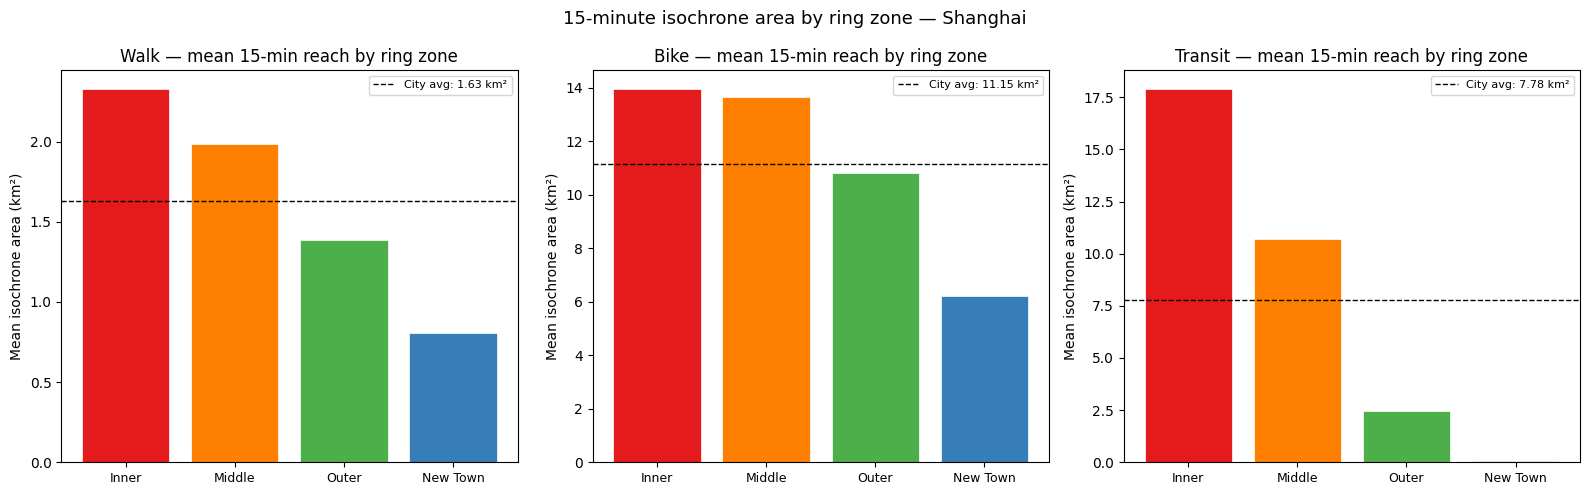

Ring-zone area chart saved.


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ring_order = ['inner_ring', 'middle_ring', 'outer_ring', 'new_town']
colours    = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8']

for ax, (label, gdf) in zip(axes, [
    ('Walk',    iso_walk),
    ('Bike',    iso_bike),
    ('Transit', iso_transit)
]):
    means = (
        gdf.groupby('ring_zone')['iso_area_m2']
           .mean()
           .reindex(ring_order)
           / 1e6
    )
    bars = ax.bar(range(len(ring_order)), means.values,
                  color=colours, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(ring_order)))
    ax.set_xticklabels(['Inner', 'Middle', 'Outer', 'New Town'],
                       fontsize=9)
    ax.set_ylabel('Mean isochrone area (km²)')
    ax.set_title(f'{label} — mean 15-min reach by ring zone')
    ax.axhline(means.mean(), color='black', lw=1, ls='--',
               label=f'City avg: {means.mean():.2f} km²')
    ax.legend(fontsize=8)

plt.suptitle('15-minute isochrone area by ring zone — Shanghai', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/iso_area_by_ring.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ring-zone area chart saved.")

---
## 12 · like Teacher-style visualization

In [60]:
# ── Teacher-style visualization helpers ─────────────────────────────────────

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely.geometry import Point, mapping
from shapely.ops import unary_union

WGS84 = "EPSG:4326"

# Use projected CRS for area/buffer maps
if "UTM51N" not in globals():
    UTM51N = "EPSG:32651"

# If your road graph uses EPSG:4576, use that for network plots
if "ROAD_CRS" not in globals():
    ROAD_CRS = "EPSG:4576"


def get_iso_row(iso_gdf, cell_id):
    row = iso_gdf[iso_gdf["cell_id"] == cell_id]
    if len(row) == 0 or row.geometry.isna().all():
        return None
    return row.iloc[0]


def get_nearest_cell_id(grid_df, lon, lat):
    tmp = grid_df.copy()
    tmp["_dist"] = ((tmp["lon"] - lon) ** 2 + (tmp["lat"] - lat) ** 2) ** 0.5
    cid = tmp.loc[tmp["_dist"].idxmin(), "cell_id"]
    return cid


def get_cell_center(grid_df, cell_id):
    row = grid_df[grid_df["cell_id"] == cell_id].iloc[0]
    return float(row["lon"]), float(row["lat"])

In [61]:
# ── Select one origin cell for teacher-style isochrone maps ──────────────────

CHECK_LON, CHECK_LAT = 121.4737, 31.2304  # People's Square

check_id = get_nearest_cell_id(grid, CHECK_LON, CHECK_LAT)
check_lon, check_lat = get_cell_center(grid, check_id)

print("Selected origin cell:", check_id)
print("Origin lon/lat:", check_lon, check_lat)

Selected origin cell: SH_016432
Origin lon/lat: 121.47490541891369 31.23140188158204


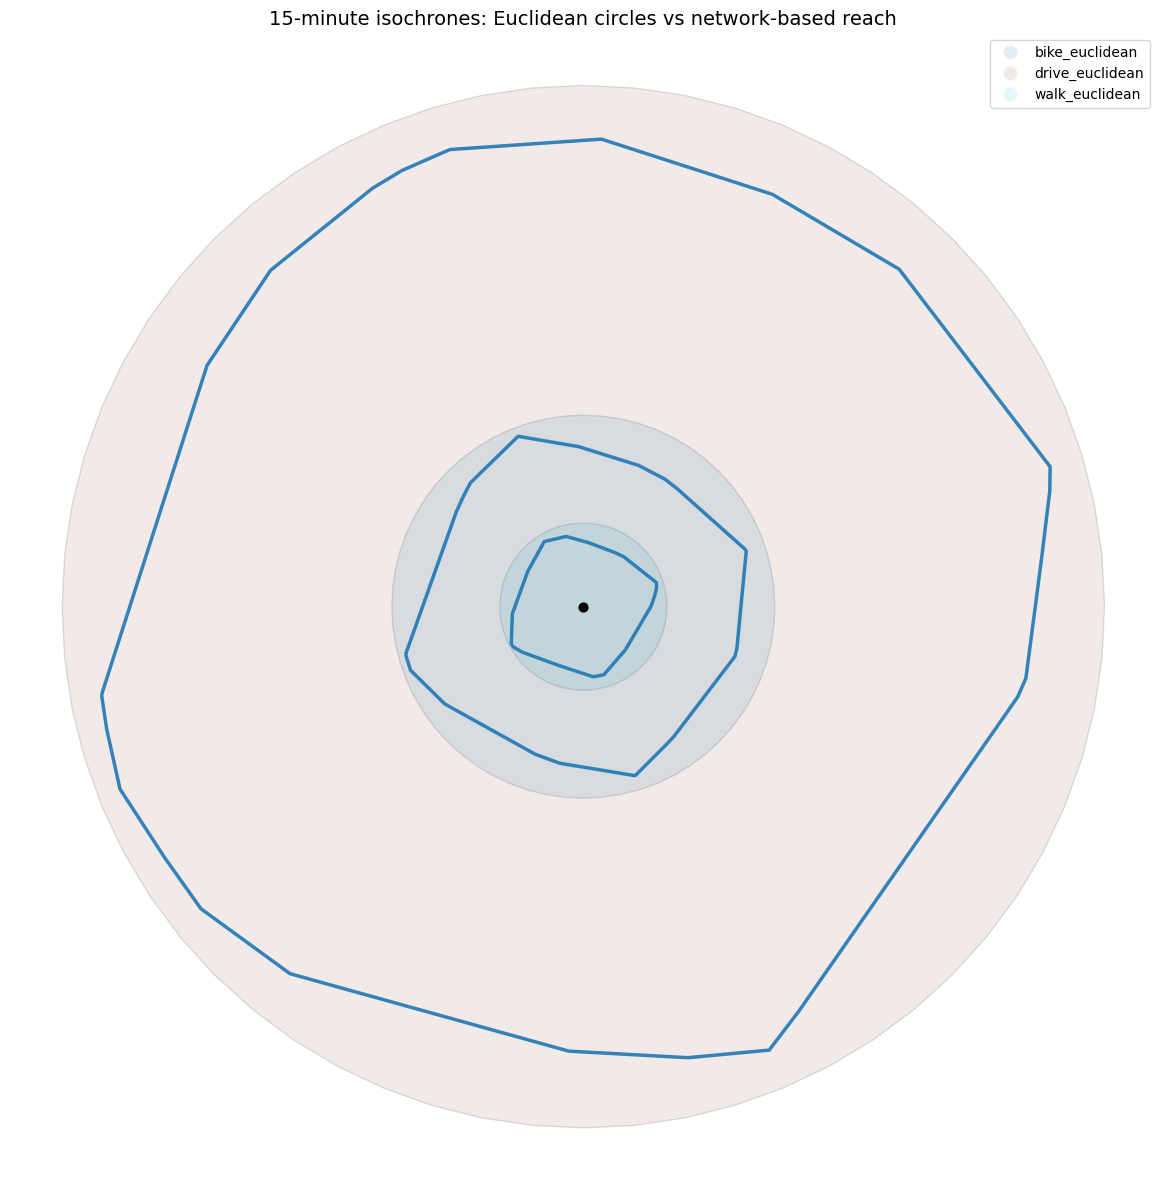

Saved: /kaggle/working/teacher_style_isochrone_circles_vs_network.png


In [63]:
# ── Static teacher-style map: Euclidean circles vs network isochrones ─────────

origin = gpd.GeoDataFrame(
    {"name": ["origin"]},
    geometry=[Point(check_lon, check_lat)],
    crs=WGS84
)

origin_proj = origin.to_crs(ROAD_CRS)

# Euclidean reference circles
circle_walk = origin_proj.geometry.iloc[0].buffer(15 * 60 * SPEED_WALK)
circle_bike = origin_proj.geometry.iloc[0].buffer(15 * 60 * SPEED_BIKE)
circle_drive = origin_proj.geometry.iloc[0].buffer(15 * 60 * SPEED_CAR)

ref_circles = gpd.GeoDataFrame(
    {
        "mode": ["walk_euclidean", "bike_euclidean", "drive_euclidean"],
        "geometry": [circle_walk, circle_bike, circle_drive]
    },
    crs=ROAD_CRS
)

# Precise network-based isochrones
iso_parts = []

for label, gdf in [
    ("walk_network", iso_walk),
    ("bike_network", iso_bike),
    ("drive_network", iso_drive),
]:
    row = get_iso_row(gdf, check_id)
    if row is not None:
        iso_parts.append({
            "mode": label,
            "geometry": row.geometry
        })

iso_precise = gpd.GeoDataFrame(iso_parts, crs=WGS84).to_crs(ROAD_CRS)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot Euclidean reference circles
ref_circles.plot(
    ax=ax,
    column="mode",
    alpha=0.12,
    edgecolor="black",
    linewidth=1,
    legend=True
)

# Plot network isochrones
if len(iso_precise) > 0:
    iso_precise.boundary.plot(
        ax=ax,
        linewidth=2.5,
        alpha=0.9
    )

# Plot origin
origin_proj.plot(
    ax=ax,
    color="black",
    markersize=40,
    zorder=5
)

ax.set_title(
    "15-minute isochrones: Euclidean circles vs network-based reach",
    fontsize=14
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("/kaggle/working/teacher_style_isochrone_circles_vs_network.png",
            dpi=200, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/teacher_style_isochrone_circles_vs_network.png")

In [64]:
# ── Area comparison table, teacher-style ─────────────────────────────────────

area_rows = []

# Euclidean circle areas
for _, row in ref_circles.iterrows():
    area_rows.append({
        "Name": row["mode"],
        "area_m2": row.geometry.area,
        "area_km2": row.geometry.area / 1e6
    })

# Network isochrone areas
for _, row in iso_precise.iterrows():
    area_rows.append({
        "Name": row["mode"],
        "area_m2": row.geometry.area,
        "area_km2": row.geometry.area / 1e6
    })

area_table = pd.DataFrame(area_rows).sort_values("area_m2", ascending=False)

display(area_table)

,Name,area_m2,area_km2
2,drive_euclidean,175022228.6661,175.0222
5,drive_network,133397739.3018,133.3977
1,bike_euclidean,23633971.2900,23.6340
4,bike_network,16692325.9636,16.6923
0,walk_euclidean,4494074.9062,4.4941
3,walk_network,2927535.9819,2.9275


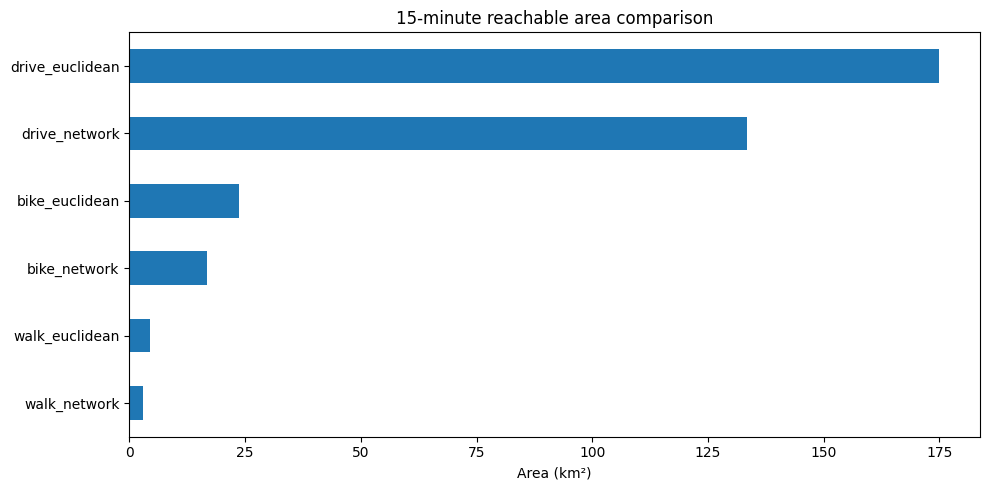

Saved: /kaggle/working/teacher_style_area_comparison.png


In [65]:
# ── Teacher-style area comparison plot ───────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

area_table.sort_values("area_km2").plot(
    x="Name",
    y="area_km2",
    kind="barh",
    ax=ax,
    legend=False
)

ax.set_xlabel("Area (km²)")
ax.set_ylabel("")
ax.set_title("15-minute reachable area comparison")
plt.tight_layout()

plt.savefig("/kaggle/working/teacher_style_area_comparison.png",
            dpi=200, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/teacher_style_area_comparison.png")

In [67]:
# ── Reachable road edges map, teacher-style ──────────────────────────────────

import networkx as nx


def reachable_edges_gdf(G, lon, lat, max_seconds=15*60, weight="travel_time"):
    """
    Return road edges reachable from one origin within max_seconds.
    Edge color value = minimum travel time to either endpoint.
    """
    origin_node = nearest_local_node(G, lat, lon)

    lengths = nx.single_source_dijkstra_path_length(
        G,
        origin_node,
        cutoff=max_seconds,
        weight=weight
    )

    rows = []

    for u, v, data in G.edges(data=True):
        if u in lengths or v in lengths:
            tt = min(lengths.get(u, np.inf), lengths.get(v, np.inf))

            geom = data.get("geometry", None)
            if geom is None:
                geom = None

            rows.append({
                "u": u,
                "v": v,
                "travel_time_s": tt,
                "geometry": geom
            })

    out = gpd.GeoDataFrame(rows, crs=G.graph["crs"])
    out = out.dropna(subset=["geometry"]).copy()

    return out


reachable_walk = reachable_edges_gdf(G_walk, check_lon, check_lat, 15*60)
reachable_bike = reachable_edges_gdf(G_bike, check_lon, check_lat, 15*60)
reachable_drive = reachable_edges_gdf(G_drive, check_lon, check_lat, 15*60)

print("Reachable walk edges:", len(reachable_walk))
print("Reachable bike edges:", len(reachable_bike))
print("Reachable drive edges:", len(reachable_drive))

Reachable walk edges: 1940
Reachable bike edges: 3537
Reachable drive edges: 10896


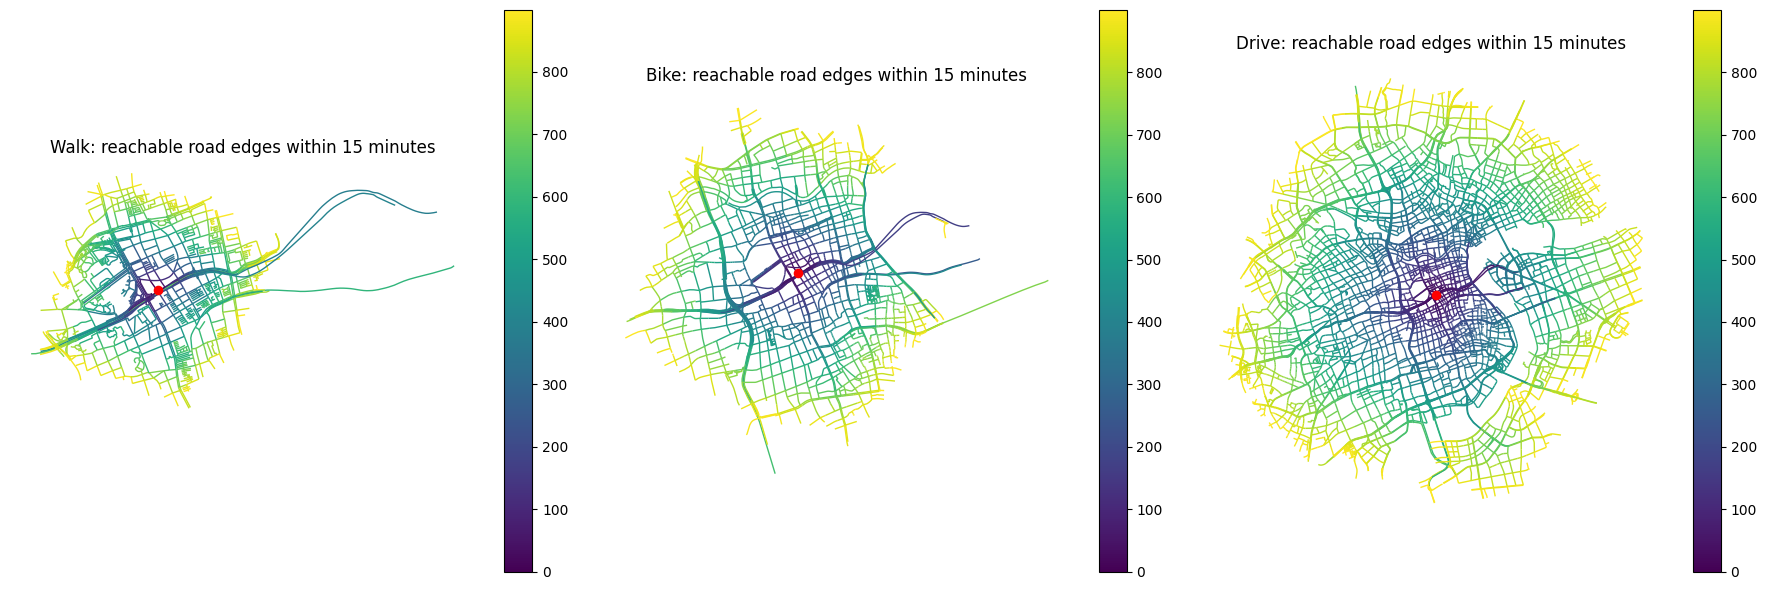

Saved: /kaggle/working/teacher_style_reachable_edges.png


In [69]:
# ── Plot reachable road edges by travel time ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label, gdf in [
    (axes[0], "Walk", reachable_walk),
    (axes[1], "Bike", reachable_bike),
    (axes[2], "Drive", reachable_drive),
]:
    if len(gdf) > 0:
        gdf.plot(
            ax=ax,
            column="travel_time_s",
            cmap="viridis",
            linewidth=1,
            legend=True
        )

    origin_proj.plot(ax=ax, color="red", markersize=35, zorder=5)

    ax.set_title(f"{label}: reachable road edges within 15 minutes")
    ax.set_axis_off()

plt.tight_layout()
plt.savefig("/kaggle/working/teacher_style_reachable_edges.png",
            dpi=200, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/teacher_style_reachable_edges.png")

In [71]:
# ── Interactive map: all four 15-min isochrones ──────────────────────────────

m = folium.Map(
    location=[check_lat, check_lon],
    zoom_start=13,
    tiles="CartoDB positron"
)

MODE_STYLES = {
    "walk":    {"color": "#e41a1c", "fillOpacity": 0.20},
    "bike":    {"color": "#377eb8", "fillOpacity": 0.18},
    "drive":   {"color": "#984ea3", "fillOpacity": 0.12},
    "transit": {"color": "#4daf4a", "fillOpacity": 0.16},
}

for label, gdf in [
    ("walk", iso_walk),
    ("bike", iso_bike),
    ("drive", iso_drive),
    ("transit", iso_transit),
]:
    row = get_iso_row(gdf, check_id)

    if row is None:
        print(f"{label}: missing geometry")
        continue

    style = MODE_STYLES[label]

    folium.GeoJson(
        mapping(row.geometry),
        name=f"15-min {label}",
        style_function=lambda x, style=style: {
            "fillColor": style["color"],
            "color": style["color"],
            "weight": 2,
            "fillOpacity": style["fillOpacity"]
        },
        tooltip=f"15-min {label}"
    ).add_to(m)

folium.CircleMarker(
    location=[check_lat, check_lon],
    radius=6,
    color="black",
    fill=True,
    fill_color="black",
    tooltip=f"Origin cell: {check_id}"
).add_to(m)

folium.LayerControl().add_to(m)

m.save("/kaggle/working/teacher_style_interactive_isochrones.html")
m